
<div style="background-color:#5F9EA0; 
            color:white; 
            padding:15px; 
            border-radius:10px; 
            text-align:center; 
            font-size:30px; 
            font-weight:bold;">
    Offensive Tweet Detection<br>
    <span style="font-size:20px; font-weight:normal;">
        Group 13: Laura Jonker, Anna Attuch, Anna Grenz
    </span>
</div>

<div style="background-color:#D2EFF1;
            color:#333333;
            padding:12px 16px;
            border-radius:10px;
            margin:10px 0;">
   </b> 

<h1 id="setup" 
    style="font-size:30px;
           background-color:#D2EFF1;
           color:#5F9EA0;
           font-weight:bold;
           padding:10px;
           border-radius:10px;">
    Introduction
</h1>

This notebook explores the classification of tweets on Twitter.  The main objective is to build a machine learning model that can accurately distinguish between **offensive** and **non-offensive** tweets.

We begin by preprocessing and tokenizing the text data, followed by extracting multiple feature types to capture different aspects of language:
- **TF-IDF representations** to model word frequency and importance,  
- **Sentiment- and tweet-level indicators** (e.g., positivity, negativity, lexical variety), and  
- **Pre-trained GloVe embeddings** to incorporate semantic meaning and context.

All features are combined into sparse matrices and used as inputs for **regularized logistic regression models**—specifically, *Lasso*, *Ridge*, and *Elastic Net*.  
Each model is trained and validated using cross-validated AUC to ensure robustness and comparability.

Performance metrics and visualizations are employed to interpret model behavior and assess how different feature sets —particularly the inclusion of word embeddings— affect classification accuracy.  

Finally, the best-performing model, a the Lasso including tweet embeddings, is applied to the test data to generate predictions for submission.</div>


<h1 id = setup style = 'font-size:30px; background: linear-gradient(90deg, #5F9EA0, #7AC5CD, #8EE5EE); color: white; padding: 10px;  border-radius: 10px;'>
    1. Setup Notebook
</h1




In [42]:
## Importing packages
library(tidyverse) 
library(tidytext)
library(Matrix)
library(ggwordcloud)
library(glmnet)

## Limiting the number of rows that can be displayed
options(repr.matrix.max.rows = 8)

## Data attached to this notebook
list.files(path = "../input")

[1] "bda-2025-sentiment-from-customer-reviews"    
[2] "glove-embeddings"                            
[3] "glove-global-vectors-for-word-representation"

<h1 id = setup style = 'font-size:30px; background: linear-gradient(90deg, #5F9EA0, #7AC5CD, #8EE5EE); color: white; padding: 10px;  border-radius: 10px;'>
    2. Read Data
</h1

<div style="background-color:#D2EFF1;
            color:#333333;
            padding:12px 16px;
            border-radius:10px;
            margin:10px 0;">
   </b> The data contains a large collection of tweets and commands posted on other platforms. The majority of the data is from twitter and was obtained through keyboard-based sampling. Therefore the dataset remains biased towards overt expressions and is not fully representative of the broader twitter population.


Machine Learning Models and Methods that should be considered in this case are: Naive Bayes: works well with the word frequencies because of the conditional independence assumption; Logistic regression: a baseline for binary classification; Regularized regression: Text data means thousands of features (words) and Regularization: avoids overfitting and selects only important features; Ensemble trees: Can capture non linear interactions between features (words).

 The Bayes error rate is the theoretical minimum of error. It arises because there is no clear dividing line between classes. Models should strive for this lower limit. In our offensive-tweet setting, this floor exists because some tweets are inherently ambiguous or context dependent. Examples include sarcasm, quotes of slurs in a non-offensive way, and reclaimed terms. Human annotators could also disagree on borderline cases, which adds label noise. On top of that, our preprocessing removed cues like emojis, hashtags, and punctuation that often disambiguate tone. Adding richer features such as GloVe embeddings and tweet-level indicators can reduce class overlap and move us closer to this limit, but it cannot remove it. We should therefore expect performance to plateau near this irreducible level rather than go to zero.

Our text data is already heavily pre-processed: normalization (removing links, mentions, emojis/newlines), expansion of contractions, grammar fixes via Word2Vec/Gensim, removal of dates, accents, and numbers (with remaining numerics written out), stripping special characters, profanity normalization, and lowercasing. This cleaning reduces noise and inconsistencies that could hinder learning. However, in social media, items like hashtags, mentions, punctuation, or creative spellings can carry signal (e.g., topic cues or filter evasion). So while the corpus is cleaner, some potentially predictive information may have been lost. </div>

In [43]:
dir("../input", recursive = TRUE) # what is in our folders

[1] "bda-2025-sentiment-from-customer-reviews/hate_tweets_test.csv" 
 [2] "bda-2025-sentiment-from-customer-reviews/hate_tweets_train.csv"
 [3] "bda-2025-sentiment-from-customer-reviews/sample_submission.csv"
 [4] "glove-embeddings/glove.6B.100d.txt"                            
 [5] "glove-embeddings/glove.6B.200d.txt"                            
 [6] "glove-embeddings/glove.6B.300d.txt"                            
 [7] "glove-embeddings/glove.6B.50d.txt"                             
 [8] "glove-global-vectors-for-word-representation/glove.6B.100d.txt"
 [9] "glove-global-vectors-for-word-representation/glove.6B.200d.txt"
[10] "glove-global-vectors-for-word-representation/glove.6B.50d.txt"

In [44]:
# Find the right file paths
train_filepath <- dir("..", pattern = "train.csv", recursive = TRUE, full.names = TRUE)
test_filepath <- dir("..", pattern = "test.csv", recursive = TRUE, full.names = TRUE)

# Read in the csv files
traindat <- read_csv(train_filepath, col_types = "cci") 
testdat <- read_csv(test_filepath, col_types = "cc") 

<h2 id = setup style = 'font-size:20px; background: linear-gradient(90deg, #5F9EA0, #7AC5CD, #8EE5EE); color: white; padding: 10px;  border-radius: 10px;'>
    2.1 Visualization of Offensive vs Non-Offensive Tweets
</h2

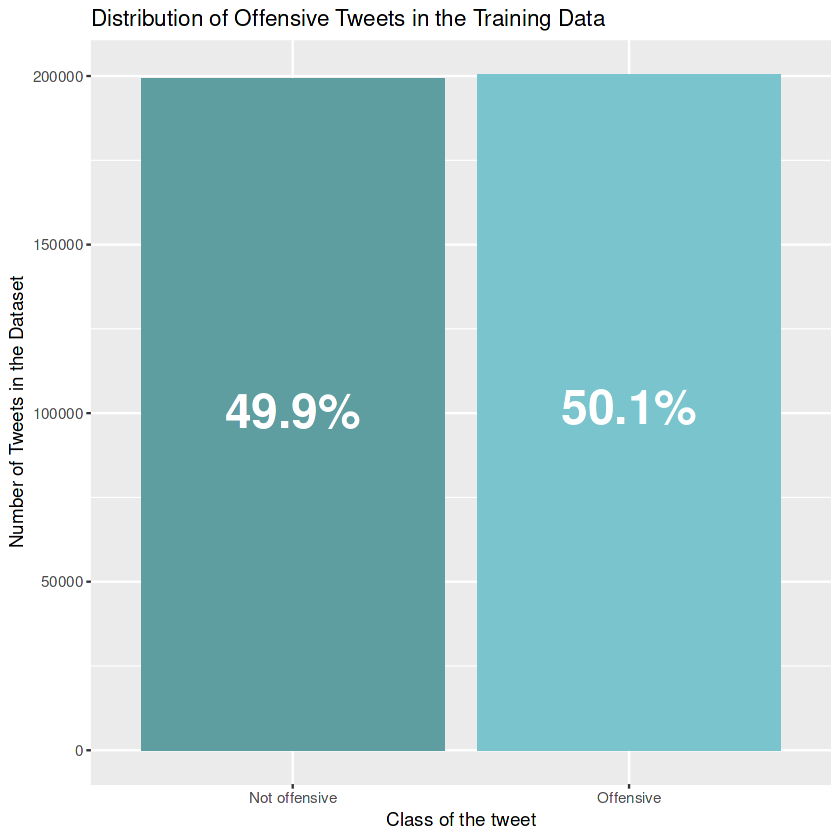

In [45]:
# Turning factors into labels
traindat$label_factor <- factor(
    traindat$label,
    levels = c(0,1),
    labels = c("Not offensive", "Offensive")
)

# Compute counts and percentages
label_counts <- traindat |>
    count(label_factor) |>
    mutate(percentage = n / sum(n) * 100)

# Bar chart showing distribution of offensive tweets
ggplot(label_counts, aes(x = label_factor, y = n, fill = label_factor)) +
    geom_col() +
    geom_text(aes(label = paste0(round(percentage, 1), "%")),
              vjust = 10, size = 10, fontface= "bold", colour = "white") +
    labs(title = "Distribution of Offensive Tweets in the Training Data", 
         x = "Class of the tweet",
         y = "Number of Tweets in the Dataset") +
    scale_fill_manual(values = c("#5F9EA0", "#7AC5CD")) +
    theme(legend.position = "none")

<div style="background-color:#D2EFF1;
            color:#333333;
            padding:12px 16px;
            border-radius:10px;
            margin:10px 0;">
   </b> 
    
    
The distribution shown confirms our earlier assumptions based on the collected data. The data is not representative of a Twitter community. Many studies show that, when tweets are randomly extracted, the distribution of non-offensive to offensive tweets usually lies between 1% and 32% (Çöltekin, 2020; Evkoski et al., 2021; Zampieri et al., 2019). Although, it is also shown that this proportion changes significantly with language and context (Çöltekin, 2020; Evkoski et al., 2021; Mubarak et al., 2022). Moreover, evidence indicates that emojis are effective indicators for detecting offensive tweets, therefore, it is important to note that our dataset does not include them (Mubarak et al., 2022).



References:

Çöltekin, Ç. (2020). A corpus of Turkish offensive language on social media. In *Proceedings of the Twelfth Language Resources and Evaluation Conference* (pp. 6174–6184). European Language Resources Association. https://aclanthology.org/2020.lrec-1.758/

Evkoski, B., Pelicon, A., Mozetič, I., Ljubešić, N., & Novak, P. (2022). Retweet communities reveal the main sources of hate speech. *PLOS ONE, 17*(5), e0265602. https://doi.org/10.1371/journal.pone.0265602

Mubarak, H., Hassan, S., & Chowdhury, S. (2023). Emojis as anchors to detect Arabic offensive language and hate speech. *Natural Language Engineering, 29*, 1436–1457. https://doi.org/10.1017/S1351324923000402

Zampieri, M., Malmasi, S., Nakov, P., Rosenthal, S., Farra, N., & Kumar, R. (2019). 
Predicting the type and target of offensive posts in social media. *Proceedings of the 2019 Conference of the North American Chapter of the Association for Computational Linguistics: Human Language Technologies (NAACL-HLT 2019)*, 1415–1420. https://doi.org/10.18653/v1/N19-1144

<h1 id = setup style = 'font-size:30px; background: linear-gradient(90deg, #5F9EA0, #7AC5CD, #8EE5EE); color: white; padding: 10px;  border-radius: 10px;'>
    3. Data Preprocessing
</h1

<h2 id = setup style = 'font-size:20px; background: linear-gradient(90deg, #5F9EA0, #7AC5CD, #8EE5EE); color: white; padding: 10px;  border-radius: 10px;'>
    3.1 Tokenization
</h2

In [46]:
## Tokenize on word level 
tokenized_tweets <- traindat |> 
    unnest_tokens(token, tweet, token = "words") |> # tokenize tweets at word level
    count(id, token) # count tokens within tweets as 'n'

<div style="background-color:#D2EFF1;
            color:#333333;
            padding:12px 16px;
            border-radius:10px;
            margin:10px 0;">
   </b> 

In this step, we tokenize the tweets. That is, we break each tweet into individual words (tokens).
This allows us to analyze the text at the word level, count how often each word appears in each tweet, and later build numerical features, like TF-IDF or embeddings.
We chose not to use the whole dataset for time efficiency when fitting models. Moreover, even with a compartively small subsection, the dataset is incredibly large. </div>

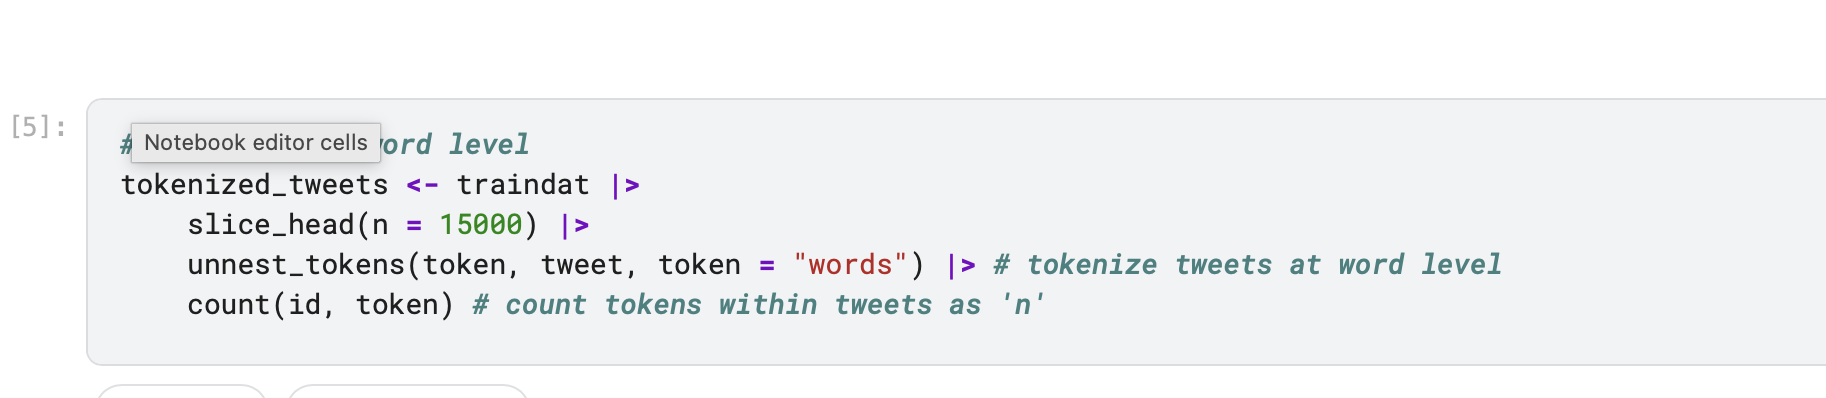

<h2 id = setup style = 'font-size:20px; background: linear-gradient(90deg, #5F9EA0, #7AC5CD, #8EE5EE); color: white; padding: 10px;  border-radius: 10px;'>
    3.2 Word-Cloud of Offensive vs Non Offensive Tokens
</h2

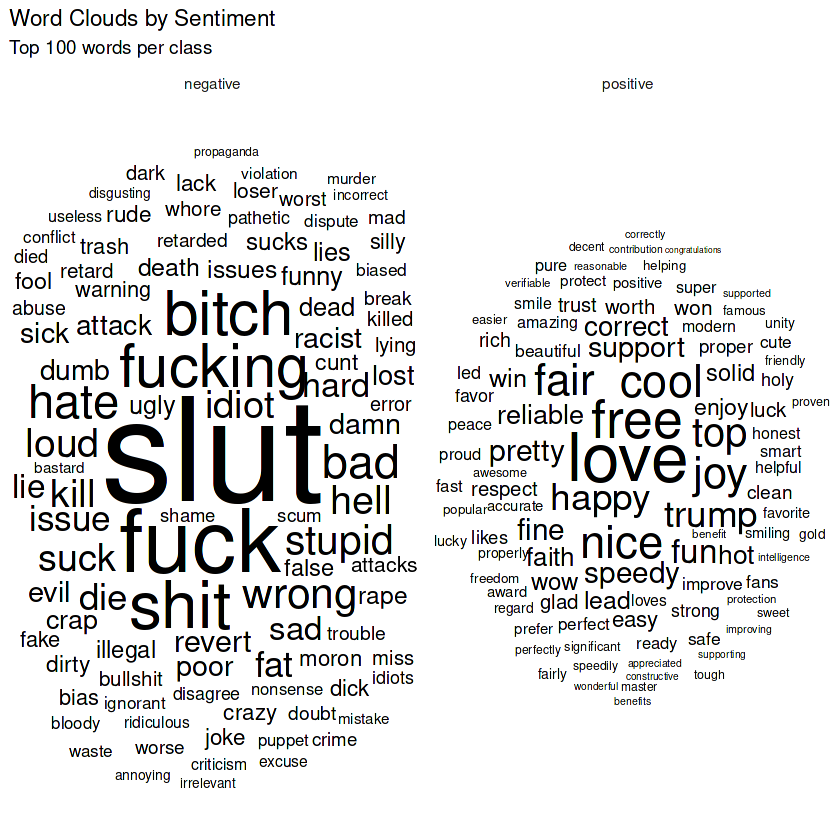

In [47]:
tokenized_tweets_nostop <- tokenized_tweets |> 
    anti_join(stop_words, by = c("token" = "word")) # exclude stopwords for visualization 

sent_tokens <- tokenized_tweets_nostop |>
    inner_join(get_sentiments("bing"), # assign sentiments to words for visualization
               by = c("token" = "word"), 
               relationship = "many-to-many")

sent_counts <- sent_tokens |>
    count(sentiment, token, wt = n, sort = TRUE)

top_n_per_class <- 100 # select 100 most used words for negative and positive

sent_counts_top <- sent_counts |>
    group_by(sentiment) |>
    slice_max(order_by = n, n = top_n_per_class) |>
    ungroup()

set.seed(123) # visualize
ggplot(sent_counts_top, aes(label = token, size = n)) +
    geom_text_wordcloud_area() +
    scale_size_area(max_size = 50) +
    theme_minimal() +
    facet_wrap(~ sentiment, scales = "free") +
    labs(title = "Word Clouds by Sentiment",
         subtitle = paste0("Top ", top_n_per_class, " words per class"),
         x = NULL, y = NULL)


<div style="background-color:#D2EFF1;
            color:#333333;
            padding:12px 16px;
            border-radius:10px;
            margin:10px 0;">
   </b> We examined word clouds of the 100 most frequent words in offensive and non-offensive tweets to visually identify common vocabulary patterns in language use between the two classes.
First of all, it's interesting to note that trump is stated as a positive word. While trump may be used in a positive context, it is also the name of controversial US president Donald Trump, meaning it could have negative connotations. We will therefore exclude it from the Bing's sentiment list. 
The word clouds reveal a lexical split, offensive tweets are dominated by explicit insults and profanity, while non-offensive tweets use positive or neutral terms.  </div>


In [48]:
sentiments <- get_sentiments("bing") |>
    filter(!word == "trump") # remove "trump" from sentiment tibble because not per se positive word

<h2 id = setup style = 'font-size:20px; background: linear-gradient(90deg, #5F9EA0, #7AC5CD, #8EE5EE); color: white; padding: 10px;  border-radius: 10px;'>
   3.3 Stopwords
</h2


<div style="background-color:#D2EFF1;
            color:#333333;
            padding:12px 16px;
            border-radius:10px;
            margin:10px 0;">
   </b> 
    
We chose to retain stopwords because removing them would reduce valuable information in our dataset, which is already limited by its artificial 50/50 balance of offensive and non-offensive tweets. Stopwords often encode subtle cues such as negation, pronouns, and tone, which are important for distinguishing implicit or indirect offensiveness (Guo et al., 2024; Kumari et al., 2023). Eliminating them risks discarding these contextual signals and may worsen performance and generalizability, particularly in datasets that are not fully representative of real-world distributions (Raza et al., 2023).


References: 

Guo, X., Adnan, H., & Abidin, M. (2024). Detecting offensive language on Malay social media: A zero-shot, cross-language transfer approach using dual-branch mBERT. *Applied Sciences, 14*(13), 5777. https://doi.org/10.3390/app14135777

Kumari, A., Garge, A., Raj, P., Kumar, G., Singh, J., & Alryalat, M. (2023). Classification of offensive tweets in Marathi language using machine learning models. In *Intelligent Systems and Applications* (pp. 261–273). Springer. https://doi.org/10.1007/978-3-031-48876-4_20

Raza, M., Mahoto, N., Hamdi, M., Reshan, M., Rajab, A., & Shaikh, A. (2023). Detection of offensive terms in resource-poor language using machine learning algorithms. *Applied Artificial Intelligence, 37*(1), 1–16.

<h1 id = setup style = 'font-size:30px; background: linear-gradient(90deg, #5F9EA0, #7AC5CD, #8EE5EE); color: white; padding: 10px;  border-radius: 10px;'>
   4. Tweet Embeddings
</h1

<div style="background-color:#D2EFF1;
            color:#333333;
            padding:12px 16px;
            border-radius:10px;
            margin:10px 0;">
   </b> We decided to implement the code provided in the notebook in-class in our competition notebook. Please note that the first lines of code were extracted directly from the notebook. </div>

In [49]:
# Embeddings are stored in order of frequency of token usage in English — import the 40k most important
embeddings_file <- list.files("../input", recursive = TRUE, 
                              pattern = "300d.txt", 
                              full = TRUE)
embeddings <- readLines(embeddings_file, n = 40000)
embeddings |> length() # check number of lines read

[1] 40000

In [50]:
# Convert the lines into rows of a matrix 
emb <- strsplit(embeddings, " ")
emb <- do.call(rbind, emb)
colnames(emb) <- c("token", paste0("x", 1:300))

In [51]:
# Convert the text based matrix into a numeric matrix
model <- emb[,-1]
rownames(model) <- emb[,1]
mode(model) <- "numeric" # changing the mode forces R to interpret the text in model as numbers

# Inspect
model

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,⋯,x291,x292,x293,x294,x295,x296,x297,x298,x299,x300
the,0.046560,0.213180,-0.0074364,-0.458540,-0.035639,0.236430,-0.28836,0.21521,-0.134860,-1.6413,⋯,-0.013064,-0.296860,-0.079913,0.195000,0.031549,0.28506,-0.087461,0.0090611,-0.209890,0.053913
",",-0.255390,-0.257230,0.1316900,-0.042688,0.218170,-0.022702,-0.17854,0.10756,0.058936,-1.3854,⋯,0.075968,-0.014359,-0.073794,0.221760,0.146520,0.56686,0.053307,-0.2329000,-0.122260,0.354990
.,-0.125590,0.013630,0.1030600,-0.101230,0.098128,0.136270,-0.10721,0.23697,0.328700,-1.6785,⋯,0.060148,-0.156190,-0.119490,0.234450,0.081367,0.24618,-0.152420,-0.3422400,-0.022394,0.136840
of,-0.076947,-0.021211,0.2127100,-0.722320,-0.139880,-0.122340,-0.17521,0.12137,-0.070866,-1.5721,⋯,-0.366730,-0.386030,0.302900,0.015747,0.340360,0.47841,0.068617,0.1835100,-0.291830,-0.046533
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
calamities,0.072944,0.189580,-0.0080281,0.12884,-0.140580,0.569860,0.070639,-0.29197,0.0018218,-0.090222,⋯,-0.17498,-0.4760100,0.26331,-0.527250,0.079951,0.21163,-0.30071,0.41259,0.203320,0.18298
flashlights,-0.157170,-0.488030,0.1526400,-0.39228,-0.023823,0.066149,0.094734,0.17739,0.0584220,-0.185070,⋯,-0.87520,-0.0008292,-0.11646,0.041583,-1.028000,-0.19607,0.43634,0.19656,0.082773,0.43783
droo,0.227980,-0.717990,0.1549500,0.17243,0.125690,-0.158770,0.704220,-0.28861,-0.6374000,0.452550,⋯,0.25000,-0.1528400,0.57350,-0.673290,-0.192580,-0.50491,-0.13775,-0.13660,-0.023493,-0.19447
midwife,-0.278300,-0.043744,-0.2449400,0.27080,-0.063527,-0.550620,-0.488230,0.40857,-0.3341400,0.488040,⋯,-0.46291,0.2872200,0.12031,-0.273480,-0.086425,-0.52287,0.58171,0.17137,-0.133440,0.90549


<div style="background-color:#D2EFF1;
            color:#333333;
            padding:12px 16px;
            border-radius:10px;
            margin:10px 0;">
   </b>  A model was created that represents the 40,000 most frequently used words in the English language as vectors in a 300-dimensional space. This word embedding model will later be used to identify and match words within the tweet dataset. We then create an embedding for each tweet.
This table shows a word embedding matrix, where each row corresponds to a specific word, for example, “the”, “of”, “calamities”, “midwife”, and each column (x1–x300) represents one of the embedding dimensions.
Each numerical value indicates how strongly a word is associated with that particular dimension.
In this case, the matrix has 40,000 words (rows) and 300 embedding dimensions (columns), meaning every word is represented as a 300-dimensional vector capturing its semantic meaning and contextual relationships in the language model. </div>



<h2 id = setup style = 'font-size:20px; background: linear-gradient(90deg, #5F9EA0, #7AC5CD, #8EE5EE); color: white; padding: 10px;  border-radius: 10px;'>
   4.1 Build Document-Term Matrix
</h2

In [52]:
# Example sentences
text <- traindat |>
    pull(tweet)

# Show first few tweets
head(text)

# Calculate the DTM 
dtm <- data.frame(doc = seq_along(text), text = text) |> 
    unnest_tokens(input = text, output = term) |> 
    count(doc, term) |> # using counts
    cast_sparse(doc, term, n)

# Ensure all tweets are kept (even if no tokens are present in tweet)
all_docs <- seq_along(text)

if (nrow(dtm) < length(all_docs)) {
    missing_docs <- setdiff(all_docs, as.integer(rownames(dtm)))
    zeros <- Matrix(0, nrow = length(missing_docs), ncol = ncol(dtm), sparse = TRUE)
    rownames(zeros) <- missing_docs
    colnames(zeros) <- colnames(dtm)
    dtm <- rbind(dtm, zeros)
    dtm <- dtm[order(as.integer(rownames(dtm))), ]  # restore order
}

# Assign row names as original tweets for easy reference
rownames(dtm) <- text

# Inspect
dim(dtm)

[1] "not a problem have a nice day"                                                                                                                                                                                                                                                                         
[2] "london at this time of the year is such a lovely bright and vibrant place i am in love with the views the tiny alleys the friendly people here it is all so wonderful all lovely and colorful even the big bright colorful mosque in regents park well perhaps everything but that needle on the floor"
[3] "fuck you thought no this is sean king of the sean you never put something off a long time"                                                                                                                                                                                                             
[4] "american taxpayers are billed billion every year for refugees yythats absurd should be illegal when did whatever vote for that nomorerefugees"                                                                                                                                                         
[5] "and actually you gave me no pointers at all you have done nothing to help you have gotten in trouble your self so i would worry more yourself that wasting time trying to me"                                                                                                                          
[6] "when are the republican going to learn that democrat hate conservative vote"

[1] 400000 112658

<div style="background-color:#D2EFF1;
            color:#333333;
            padding:12px 16px;
            border-radius:10px;
            margin:10px 0;">
   </b>  We selected the first 15,000 tweets and tokenized them into individual words, counting how often each word appeared in each tweet. These word counts were then transformed into a sparse numerical matrix, where each row represents a tweet and each column represents a unique word. To make sure no data was lost, we added empty (zero) rows for tweets without valid tokens and assigned the original tweet texts as row labels for easier reference. </div>


<h2 id = setup style = 'font-size:20px; background: linear-gradient(90deg, #5F9EA0, #7AC5CD, #8EE5EE); color: white; padding: 10px;  border-radius: 10px;'>
   4.2 Matching DTM to GloVe Embeddings
</h2

In [53]:
# Find terms present in both DTM and embedding model
nms <- intersect(colnames(dtm), rownames(model))

# Tweets without matches in GloVe embeddings should be retained
if(length(nms) > 0){
    sentence_embeddings <- dtm[,nms] %*% model[nms,]
    # Normalize per tweet
    word_counts <- dtm[,nms] %*% rep(1, length(nms))
    sentence_embeddings <- sentence_embeddings / pmax(word_counts, 1)
} else {
    # If no words in vocab, return all-zero embeddings
    sentence_embeddings <- matrix(0, nrow = nrow(dtm), ncol = ncol(model))
}

# Inspect sentence embeddings
dim(sentence_embeddings)
head(as.matrix(sentence_embeddings))


[1] 400000    300

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,⋯,x291,x292,x293,x294,x295,x296,x297,x298,x299,x300
not a problem have a nice day,-0.14431853,0.181191143,-0.1190991429,-0.06188129,-0.068674000,0.04128800,0.0352392857,0.005582286,0.10459486,-1.772886,⋯,-0.003622714,-0.2521643,-0.06737286,0.18513610,0.2461393,0.02860114,0.11629100,-0.2453747,-0.11821529,0.07293296
london at this time of the year is such a lovely bright and vibrant place i am in love with the views the tiny alleys the friendly people here it is all so wonderful all lovely and colorful even the big bright colorful mosque in regents park well perhaps everything but that needle on the floor,-0.12510677,0.008534607,0.0002595196,-0.23440933,-0.029117661,0.10301255,-0.0348504304,0.030245027,0.10027024,-1.409831,⋯,0.024413149,-0.1496464,-0.12142754,0.14533148,0.0647793,0.08481233,0.12063827,-0.1339883,-0.08705568,0.11178746
fuck you thought no this is sean king of the sean you never put something off a long time,0.01394332,0.013765000,-0.0853758105,-0.02802492,-0.008943842,0.02479426,-0.1093133000,-0.003856684,0.11651621,-1.488616,⋯,0.032146367,-0.1455503,-0.01544863,0.12366221,0.1080564,-0.10239463,0.02989806,-0.1498330,-0.19045042,0.17639342
american taxpayers are billed billion every year for refugees yythats absurd should be illegal when did whatever vote for that nomorerefugees,-0.07126263,0.106795000,0.0489654474,0.07347900,-0.029185263,0.07206160,0.1550697895,0.020799568,-0.01930741,-1.485755,⋯,0.015504421,-0.2083620,0.15511995,0.18790905,0.1401301,-0.02438753,-0.10469373,-0.2221464,-0.14448926,-0.01335711
and actually you gave me no pointers at all you have done nothing to help you have gotten in trouble your self so i would worry more yourself that wasting time trying to me,-0.08931933,0.082452938,-0.1084383529,-0.02802418,-0.056768935,0.02317147,0.0008030588,-0.035764853,0.17579246,-1.721610,⋯,-0.041945191,-0.2560375,0.01490644,-0.02194332,0.1776837,-0.20402215,0.03542677,-0.2738421,-0.02285575,0.06623700
when are the republican going to learn that democrat hate conservative vote,-0.14822950,-0.011391000,-0.0187939583,-0.02165250,-0.107441250,0.10211696,0.1099879167,-0.043542500,0.09535817,-1.412300,⋯,0.064718342,-0.2161287,0.08850667,0.12590317,0.0203480,0.06083783,-0.14373783,-0.3306202,-0.15356050,0.22751077


<div style="background-color:#D2EFF1;
            color:#333333;
            padding:12px 16px;
            border-radius:10px;
            margin:10px 0;">
   </b> We generated sentence embeddings for each tweet using pre-trained GloVe word embeddings. We first identified all words that appear both in our DTM and in the embedding model's vocabulary. Then, for each tweet, we multiplied its word-count vector from the DTM by the corresponding GloVe vectors. This creates a weighted average embedding that captures the overall semantic meaning of each tweet. To ensure comparability, we normalized each tweets's embeddings by the total number of matched words. Tweets without any words in the GloVe vocabulary were represented with zero vectors. The result is a matrix, where each row corresponds to one tweet and each column represents an embedding dimension (here 300 different dimensions). </div>


<h2 id = setup style = 'font-size:20px; background: linear-gradient(90deg, #5F9EA0, #7AC5CD, #8EE5EE); color: white; padding: 10px;  border-radius: 10px;'>
   4.3 Creating the Sparse Matrix
</h2

In [54]:
# Convert sentence_embeddings to tibble with id
tweet_ids <- traindat |> pull(id)

sentence_embeddings_tibble <- as_tibble(as.matrix(sentence_embeddings)) |>
    mutate(id = tweet_ids) |>
    select(id, everything())

# Pivot longer for cast_sparse
sentence_embeddings_long <- sentence_embeddings_tibble |>
    pivot_longer(cols = -id, 
                 names_to = "embedding", 
                 values_to = "value")

# Cast sparse matrix (id x embedding)
sentence_embeddings_sparse <- sentence_embeddings_long |> 
    cast_sparse(id, embedding, value)

# Verify
sentence_embeddings_sparse[1:8, 1:5]

# Check dimensions
cat("Dimensions of combined matrix:", 
    dim(sentence_embeddings_sparse), 
    "\n") 

8 x 5 sparse Matrix of class "dgCMatrix"
           x1           x2            x3          x4           x5
1 -0.14431853  0.181191143 -0.1190991429 -0.06188129 -0.068674000
2 -0.12510677  0.008534607  0.0002595196 -0.23440933 -0.029117661
3  0.01394332  0.013765000 -0.0853758105 -0.02802492 -0.008943842
4 -0.07126263  0.106795000  0.0489654474  0.07347900 -0.029185263
5 -0.08931933  0.082452938 -0.1084383529 -0.02802418 -0.056768935
6 -0.14822950 -0.011391000 -0.0187939583 -0.02165250 -0.107441250
7 -0.13496873  0.035396654  0.0644477154 -0.20780580 -0.045631385
8 -0.21599500  0.037319250 -0.0453580000 -0.10820175  0.020031000

Dimensions of combined matrix: 400000 300 


<div style="background-color:#D2EFF1;
            color:#333333;
            padding:12px 16px;
            border-radius:10px;
            margin:10px 0;">
   </b> 

We reshaped the sentence embeddings into a sparse matrix format, where each row represents a tweet and each column represents one of the 300 embedding dimensions. This structure makes the embeddings compatible with our other feature matrices, like TF-IDF and sentiment features, allowing us to easily combine them later for model training. </div>

<h1 id = setup style = 'font-size:30px; background: linear-gradient(90deg, #5F9EA0, #7AC5CD, #8EE5EE); color: white; padding: 10px;  border-radius: 10px;'>
   5. Feature Engineering 
</h1


<div style="background-color:#D2EFF1;
            color:#333333;
            padding:12px 16px;
            border-radius:10px;
            margin:10px 0;">
   </b>  
    
Feature engineering is the process of creating informative variables (features) from raw data to help the model learn meaningful patterns.
In our case, we transformed tweets into numerical representations, such as TF-IDF values, occurrence indicators, and sentiment-based features, so that machine learning models can understand and differentiate offensive from non-offensive language.
This step is essential because models cannot interpret raw text directly, engineered features translate linguistic and emotional cues into measurable signals that improve prediction accuracy. </div>

In [55]:
## Compute token-level values
# Term frequency, inverse document freuquency, and the product
tf_idf <- tokenized_tweets |>
    bind_tf_idf(token, id, n)

# Occurrence
occurrence <- tokenized_tweets |> 
    mutate(occurrence = ifelse(n >= 1, 1, 0)) # if n is equal to or larger than 1, we code occurrence to be 1, as token only can be said to occur if n >= 1

# Positivity token
pos_token <- tokenized_tweets |>
    inner_join(sentiments, 
               by = c("token" = "word"), 
               relationship = "many-to-many") |>
    mutate(is_positive = ifelse(sentiment == "positive", 1, 0)) |>
    select(-sentiment) # the variable 'sentiment' was included through the innerjoin but we wish to exclude it

# Negativity token
neg_token <- tokenized_tweets |>
    inner_join(sentiments, 
               by = c("token" = "word"), 
               relationship = "many-to-many") |> 
    mutate(is_negative = ifelse(sentiment == "negative", 1, 0)) |>
    select(-sentiment)

<div style="background-color:#D2EFF1;
            color:#333333;
            padding:12px 16px;
            border-radius:10px;
            margin:10px 0;">
   </b>  
    
The **term frequency** (TF) is a measure of how often a word appears in a tweet relative to the total number of words in a tweet. If a word appears frequently in a tweet, it is important for that tweet. However, one downside to this measure is that some words are frequent in all documents and are as such not very informative. 

The **inverse document frequency** (IDF) assigns a low value to a token if it is common across all documents, whereas if it common to a document, but not in all documents, it will get a high IDF value. 

The inner product of the above values, the **TF-IDF**, measures how common a token to a certain document is, relative to its overall frequency in all documents. 

Of course, the **occurrence**, whether a word occurs in a document (tweet) or not, is not very informative yet. However, transforming the dataframe into a design matrix will show the positions of the ones in our current dataframe, which is more informative.

A **positivity** label is added to positive tokens with pos_token. With this feature all words that are considered positive in Bing's sentiment list are assigned a one. Tweets with more positive words are less likely to be offensive. 
 
Similarly a negativity label is added to **negative** tokens with neg_token. With this feature all words that are considered negative in Bing's sentiment list are assigned a one. Tweets with more negative words are more likely to be offensive. </div>

In [56]:
## Compute document-level features 
# Average positivity per tweet
tweet_positivity <- tokenized_tweets |>
    inner_join(sentiments, 
               by = c("token" = "word"),
               relationship = "many-to-many") |> # is it ok to add "many to many" or is there an underlying issue to solve?
    mutate(is_positive = ifelse(sentiment == "positive", 1, 0)) |>
    group_by(id) |>
    summarise(avg_positivity = sum(is_positive * n) / sum(n), .groups ="drop")
  
# Tf-Idf weighted positivity
tweet_positivity_TFIDF <- tokenized_tweets |>
    bind_tf_idf(token, id, n) |>
    inner_join(sentiments,
               by = c("token" = "word"),
               relationship = "many-to-many") |>
    mutate(is_positive = ifelse(sentiment == "positive", 1, 0)) |>
    group_by(id) |>
    summarise(tfidf_weighted_sentiment = 
              sum(is_positive * tf_idf) / sum(tf_idf), .groups ="drop")

# Unique word count
unique_word <- tokenized_tweets |>
    group_by(id) |>
    summarise(unique_words = length(unique(token)))

# Max repetition of negative words normalized for length
tweet_max_neg_norm <- tokenized_tweets |>
    inner_join(sentiments |> 
               filter(sentiment == "negative"),
               by = c("token" = "word")) |>
    group_by(id) |>
    summarise(max_neg_word_n_norm = 
              max(n) / sum(n), .groups= "drop")

<div style="background-color:#D2EFF1;
            color:#333333;
            padding:12px 16px;
            border-radius:10px;
            margin:10px 0;">
   </b>  
    
**Average positivity per tweet**: This feature computes the fraction of words in a tweet that are positive, weighing repeated words more heavily. Higher values indicate tweets with more positive language. It’s relevant because offensive tweets tends to have fewer positive words, so this feature helps the model distinguish between positive and potentially negative or aggressive language.

**Average positivity weighted for TF-IDF**: this feature measures the positivity of a tweet weighted by TF–IDF, giving more importance to words that are repeated in the tweet but rare across all tweets. It highlights important positive words while downweighting common neutral words, helping the model focus on words that meaningfully influence tweet sentiment.

We computed the **number of unique words per tweet**. This characteristic of a token (does the token usually occur in shorter or longer tweets) could be informative as perhaps offensive tweets are generally shorter (or longer) than non-offensive tweets are. 

**Max repetition of negative words per tweet, normalized for tweet length**: This feature captures the maximum repetition of negative words in a tweet, normalized by its length, highlighting words that are emphasized. Repeated negative words could signal offensive language, so this feature could help detect that.

</div>

<div style="background-color:#D2EFF1;
            color:#333333;
            padding:12px 16px;
            border-radius:10px;
            margin:10px 0;">
   </b>  

Other than TF-IDF, **we exclude all token-level values**. To benchmark model performance we fit a the Lasso model with only TF-IDF values for our features (i.e., tokens). This relatively simple model had a rather high accuracy; the AUC was 0.802. We noticed that with adding other token-level values, the AUC actually decreased (on the training data as well). This is likely due to the large amount of variance that is introduced when other token-level values are added (as inclusion of each value adds a matrix that has a number of columns the size of the number of unique words in the dataset). This is not true for the tweet-level features, these features just add one additional column. 

</div>


<h2 id = setup style = 'font-size:20px; background: linear-gradient(90deg, #5F9EA0, #7AC5CD, #8EE5EE); color: white; padding: 10px;  border-radius: 10px;'>
   5.1 Making Sparse Matrix of Tweet-Level Features 
</h2

In [57]:
# Full set of tweet IDs
all_ids <- traindat |> pull(id)

# Combine our custom features per tweet
custom_features <- list(tweet_positivity,
                        tweet_positivity_TFIDF,
                        tweet_max_neg_norm,
                        unique_word) |>
    reduce(full_join, by = "id") |>
    
    # Ensure every tweet ID is present
    right_join(tibble(id = all_ids), by = "id") |>
    
    # Replace NAs with 0
    mutate(across(-id, ~replace_na(., 0))) |>
    arrange(as.numeric(id))

# Convert to sparse matrix
per_tweet_sparse <- as(as.matrix(custom_features |> select(-id)), "sparseMatrix")
rownames(per_tweet_sparse) <- custom_features$id

# Verify
cat("Dimensions of per_tweet_sparse:", 
    dim(per_tweet_sparse), 
    "\n")

head(per_tweet_sparse)

Dimensions of per_tweet_sparse: 400000 4 


6 x 4 sparse Matrix of class "dgCMatrix"
  avg_positivity tfidf_weighted_sentiment max_neg_word_n_norm unique_words
1            0.5                0.5037197           1.0000000            6
2            1.0                1.0000000           .                   44
3            .                  .                   1.0000000           17
4            .                  .                   0.5000000           20
5            .                  .                   0.3333333           29
6            .                  .                   0.5000000           12

<div style="background-color:#D2EFF1;
            color:#333333;
            padding:12px 16px;
            border-radius:10px;
            margin:10px 0;">
   </b>  
    
In this step, we combined several tweet-level features, such as average positivity, TF-IDF–weighted sentiment, maximum normalized repetition of negative words, and the number of unique words, into a single matrix.
Each row represents one tweet, and each column represents one feature describing its overall tone or structure.
We converted this into a sparse matrix format so it can easily be merged with other feature sets, like embeddings and efficiently used for model training. </div>


<h2 id = setup style = 'font-size:20px; background: linear-gradient(90deg, #5F9EA0, #7AC5CD, #8EE5EE); color: white; padding: 10px;  border-radius: 10px;'>
   5.2 Creating a Tibble for TF-IDF 
</h2

In [58]:
## Extract desired columns
tfidf_features <- tf_idf |> select(id, token, tf_idf, idf)

<h2 id = setup style = 'font-size:20px; background: linear-gradient(90deg, #5F9EA0, #7AC5CD, #8EE5EE); color: white; padding: 10px;  border-radius: 10px;'>
   5.3 Non-zero Variance Features 
</h2

In [59]:
## Near-zero variance features
tfidf_keep <- tfidf_features |>
    filter(idf <= -log(0.01/100))  # keep tokens that are informative

# Number of unique tokens before and after filtering
tfidf_features |> select(token) |> unique() |> nrow()
tfidf_keep |> select(token) |> unique() |> nrow()

[1] 112658

[1] 13047

<div style="background-color:#D2EFF1;
            color:#333333;
            padding:12px 16px;
            border-radius:10px;
            margin:10px 0;">
   </b>   
    
Tokens that occur in less than 0.01% of the documents are removed. This number is arbitrary but appropriate (it will remove just 0.01% of 15.000 tweets = 1.5 tweet). Naturally it removes more tokens, but these are tokens that are either very infrequent, or misspelled, and as such are not very informative. We decrease the variance of the data while losing little information.  </div>

<h2 id = setup style = 'font-size:20px; background: linear-gradient(90deg, #5F9EA0, #7AC5CD, #8EE5EE); color: white; padding: 10px;  border-radius: 10px;'>
   5.4 Creating Sparse Matrices for TF-IDF
</h2

<div style="background-color:#D2EFF1;
            color:#333333;
            padding:12px 16px;
            border-radius:10px;
            margin:10px 0;">
   </b>  
    
Here the sparse matrix for the TF-IDF values is casted. This is necessary for the models that are used later on. Whereas the per tweet level features (average positivity, positivity weighted by TF-IDF, number of unique words, and maximum repetition of negative words) can be added next to the sparse matrix of the tweet embeddings, the TF-IDF is computed per token (i.e., word) and must be joined while in a sparse matrix format.   </div>

In [60]:
## Casting a sparse matrix for TF-IDF
# TF-IDF sparse matrix 
X_tfidf <- tfidf_keep |> cast_sparse(id, token, tf_idf)

# Function that ensures all tweet IDs are present in each matrix
all_ids <- traindat |> pull(id)

fill_missing <- function(mat) {
    missing_ids <- setdiff(all_ids, as.numeric(rownames(mat)))
    
    if(length(missing_ids) > 0) {
        zeros <- Matrix(0, nrow = length(missing_ids), ncol = ncol(mat), sparse = TRUE)
        rownames(zeros) <- missing_ids
        colnames(zeros) <- colnames(mat)
        mat <- rbind(mat, zeros)
    }
    
    # Sort by tweet id
    mat <- mat[order(as.numeric(rownames(mat))), ]
    mat
}

# Apply function
X_tfidf <- fill_missing(X_tfidf)

# Verify
dim(X_tfidf)
X_tfidf[1:8, 20:25]


[1] 400004  13047

8 x 6 sparse Matrix of class "dgCMatrix"
         you  yourself         am arrested before       for
1 .          .         .                 .      . .        
2 .          .         0.04043283        .      . .        
3 0.10072981 .         .                 .      . .        
4 .          .         .                 .      . 0.1452496
5 0.08443528 0.1160228 .                 .      . .        
6 .          .         .                 .      . .        
7 0.03544197 .         0.08386069        .      . 0.1694578
8 0.15948886 .         .                 .      . .        



<h1 id = setup style = 'font-size:30px; background: linear-gradient(90deg, #5F9EA0, #7AC5CD, #8EE5EE); color: white; padding: 10px;  border-radius: 10px;'>
   6. Joining Features with Tweet Embeddings 
</h1


In [61]:
# Create a sparse matrix with TF-IDF and the per tweet features
X_combined <- cbind(X_tfidf, per_tweet_sparse) 

# Create a sparse matrix with TF-IDF, the per tweet features, and tweet embeddings
X_combined_emb <- cbind(X_tfidf, sentence_embeddings_sparse, per_tweet_sparse)

# Verifying
X_combined[1:8, 14159:14163]
cat("\n\ndim(X): ", dim(X_combined),"\n\n") 

X_combined_emb[1:8, 14457:14463]
cat("\n\ndim(X): ", dim(X_combined_emb),"\n\n") 

ERROR: Error in cbind.Matrix(x, y, deparse.level = 0L): number of rows of matrices must match


<div style="background-color:#D2EFF1;
            color:#333333;
            padding:12px 16px;
            border-radius:10px;
            margin:10px 0;">
   </b>  
    
We combined all different features into unified matrices that will be used for model training.
The resulting two matrices, one with embeddings and one without, allow us to compare model performance and evaluate whether adding semantic information from embeddings improves offensive tweet detection. </div>

<h1 id = setup style = 'font-size:30px; background: linear-gradient(90deg, #5F9EA0, #7AC5CD, #8EE5EE); color: white; padding: 10px;  border-radius: 10px;'>
   7. Model Fitting 
</h1

<h2 id = setup style = 'font-size:20px; background: linear-gradient(90deg, #5F9EA0, #7AC5CD, #8EE5EE); color: white; padding: 10px;  border-radius: 10px;'>
   7.1 Defining Train and Test in Training Data Set
</h2

<div style="background-color:#D2EFF1;
            color:#333333;
            padding:12px 16px;
            border-radius:10px;
            margin:10px 0;">
   </b> 
    
We split our labeled training data into two parts, a training set and a validation set.
The training set is used to fit and optimize the models, while the validation set is used to evaluate how well the models generalize to unseen data.
By separating the data this way, we can measure model performance more reliably and reduce the risk of overfitting, ensuring that the final model performs well on new tweets. </div>

In [62]:
# Target variable
y <- data.frame(id = rownames(X_combined)) |> 
    inner_join(traindat, by = "id") |> 
    pull(label)

str(y)

ERROR: Error in eval(expr, envir, enclos): object 'X_combined' not found


In [63]:
# Split design matrix and target into training and validation portions
set.seed(2025)
trainidx <- caret::createDataPartition(y, p = 0.8)$Resample1

# Create a training and validation sample for X_combined
X_train <- X_combined[trainidx,]
X_valid <- X_combined[-trainidx,]

# Create a training and validation sample for X_combined_emb as well 
X_train_emb <- X_combined_emb[trainidx,]
X_valid_emb <- X_combined_emb[-trainidx,]

# Partition y into a test and training set
ytrain <- y[trainidx]
yvalid <- y[-trainidx]

ERROR: Error in eval(expr, envir, enclos): object 'y' not found


<h2 id = setup style = 'font-size:20px; background: linear-gradient(90deg, #5F9EA0, #7AC5CD, #8EE5EE); color: white; padding: 10px;  border-radius: 10px;'>
   7.2 Fitting Models
</h2

In [64]:
# Make list of different datasets
Xtrain_list <- list(
    "All features" = X_train_emb,
    "No embeddings" = X_train)

## Fit models for both datasets 
model_sets <- list()  # new list to store models for each dataset
results_list <- list()  # store summary metrics
alpha_values <- c(0.25, 0.5, 0.75) # specify different alphavalues for glmnet()

set.seed(2025) # for reproducibility

for (dataset_name in names(Xtrain_list)) {
    Xtrain <- Xtrain_list[[dataset_name]]
    
    fit_lasso <- cv.glmnet(Xtrain, ytrain, family = "binomial",
                         nfolds = 3, type.measure = "auc")
    fit_ridge <- cv.glmnet(Xtrain, ytrain, family = "binomial",
                         nfolds = 3, type.measure = "auc", alpha = 0)
    
    fit_elastic_list <- list() # list to store models for glmnet()
    
    for (a in alpha_values) {
        fit_elastic_list[[as.character(a)]] <- cv.glmnet(Xtrain, 
                                                         ytrain,
                                                         family = "binomial",
                                                         nfolds = 3,
                                                         type.measure = "auc",
                                                         alpha = a)
    }
    
    model_sets[[dataset_name]] <- list( # store models
        lasso = fit_lasso,
        ridge = fit_ridge,
        elastic = fit_elastic_list)
  
    df <- data.frame( # summary metrics for each model
        Dataset = dataset_name,
        Model = c("Lasso", "Ridge", 
                  paste0("Elastic Net (α = ", alpha_values, ")")),
        Alpha = c(1, 0, alpha_values),
        Lambda_min = c(fit_lasso$lambda.min,
                       fit_ridge$lambda.min,
                       sapply(fit_elastic_list, function(f) f$lambda.min)),
        AUC = c(max(fit_lasso$cvm),
                max(fit_ridge$cvm),
                sapply(fit_elastic_list, function(f) max(f$cvm)))
                       )
  results_list[[dataset_name]] <- df
}

# Combine results from both datasets
results_all <- do.call(rbind, results_list)
print(results_all)

# Identify the best model overall
cat("\nBest model by AUC:\n") 
print(results_all[which.max(results_all$AUC), ])


ERROR: Error in eval(expr, envir, enclos): object 'X_train_emb' not found


<div style="background-color:#D2EFF1;
            color:#333333;
            padding:12px 16px;
            border-radius:10px;
            margin:10px 0;">
   </b> 
    
We train the same family of models on two feature sets, one that includes embeddings and one that excludes them, to see whether embeddings add value. For each dataset, we fit three regularized logistic regressions: Lasso (α = 1), Ridge (α = 0), and Elastic Net with several α values (0.25, 0.5, 0.75). Each model is tuned with 3-fold cross-validation, and we record the best regularization strength (λ at lambda.min) and its cross-validated AUC. We store all fitted models and compile their metrics into a single results table across both datasets. We identify the overall best model by selecting the configuration with the highest AUC. </div>

<h2 id = setup style = 'font-size:20px; background: linear-gradient(90deg, #5F9EA0, #7AC5CD, #8EE5EE); color: white; padding: 10px;  border-radius: 10px;'>
   7.3 Model Evaluation 
</h2

In [65]:
## Validate models on earlier specified training sets
# Make list of different validation datasets
valid_sets <- list(
  "All features" = X_valid_emb,
  "No embeddings" = X_valid
)

val_results <- list() # store summary metrics for validation set

for (dataset_name in names(valid_sets)) {
    Xvalid <- valid_sets[[dataset_name]]
    models <- model_sets[[dataset_name]]  # select correct models for this dataset

    # the Lasso
    pred_class <- predict(models$lasso, Xvalid, 
                          s = models$lasso$lambda.min, 
                          type = 'class') |> as.factor()
    pred_prob  <- predict(models$lasso, Xvalid, 
                          s = models$lasso$lambda.min, 
                          type = 'response') |> drop()
    val_results[[paste0(dataset_name, "_Lasso")]] <- data.frame(
        Dataset = dataset_name,
        Model = "Lasso",
        Alpha = 1,
        Lambda_min = models$lasso$lambda.min,
        Accuracy = mean(pred_class == yvalid),
        AUC = assess.glmnet(pred_prob, newy = yvalid, family = "binomial")$auc
    )
    
    # Ridge
    pred_class <- predict(models$ridge, Xvalid, 
                          s = models$ridge$lambda.min, 
                          type = 'class') |> as.factor()
    pred_prob  <- predict(models$ridge, Xvalid, 
                          s = models$ridge$lambda.min, 
                          type = 'response') |> drop()
    val_results[[paste0(dataset_name, "_Ridge")]] <- data.frame(
        Dataset = dataset_name,
        Model = "Ridge",
        Alpha = 0,
        Lambda_min = models$ridge$lambda.min,
        Accuracy = mean(pred_class == yvalid),
        AUC = assess.glmnet(pred_prob, newy = yvalid, family = "binomial")$auc
    )

    # Elastic Net
    for (a in alpha_values) {
        fit_elastic <- models$elastic[[as.character(a)]]
        pred_class <- predict(fit_elastic, Xvalid, 
                              s = fit_elastic$lambda.min, 
                              type = 'class') |> as.factor()
        pred_prob  <- predict(fit_elastic, Xvalid, 
                              s = fit_elastic$lambda.min, 
                              type = 'response') |> drop()
        val_results[[paste0(dataset_name, "_ElasticNet_", a)]] <- data.frame(
            Dataset = dataset_name,
            Model = paste0("Elastic Net (α = ", a, ")"),
            Alpha = a,
            Lambda_min = fit_elastic$lambda.min,
            Accuracy = mean(pred_class == yvalid),
            AUC = assess.glmnet(pred_prob, newy = yvalid, family = "binomial")$auc)
    }
}

# Combine validation results into one table
val_summary <- do.call(rbind, val_results)

# Print summary
val_summary |> 
arrange(desc(AUC))

ERROR: Error in eval(expr, envir, enclos): object 'X_valid_emb' not found


In [ ]:
options(repr.plot.width = 14, repr.plot.height = 8) # for better visualization

## Visualize model performance for all datasets
# Function to extract CV results for a set of models
extract_cv_df <- function(models, dataset_name) {
    
  # Lasso
    df_lasso <- data.frame(
        log_lambda = log(models$lasso$lambda),
        mean_auc = models$lasso$cvm,
        se_auc = models$lasso$cvsd,
        model = paste0(dataset_name, " - Lasso"))
  
  # Ridge
    df_ridge <- data.frame(
        log_lambda = log(models$ridge$lambda),
        mean_auc = models$ridge$cvm,
        se_auc = models$ridge$cvsd,
        model = paste0(dataset_name, " - Ridge"))
  
  # Elastic Net, another function because multiple values for alpha
    df_elastic <- purrr::map_dfr(names(models$elastic), function(a) { 
        fit <- models$elastic[[a]]
        data.frame(
            log_lambda = log(fit$lambda),
            mean_auc = fit$cvm,
            se_auc = fit$cvsd,
            model = paste0(dataset_name, " - Elastic Net (α = ", a, ")"))
    }
                                )
    # Combine all
    bind_rows(df_lasso, df_ridge, df_elastic)
}

# Combine all datasets
df_all <- purrr::map_dfr(names(model_sets), function(dataset_name) {
    extract_cv_df(model_sets[[dataset_name]], dataset_name)
}
                        )

# Max AUC for each model
best_points <- df_all |>
    group_by(model) |>
    filter(mean_auc == max(mean_auc)) |>
    ungroup()

# Plot
ggplot(df_all, aes(x = log_lambda, y = mean_auc, color = model)) +
    geom_line(linewidth = 1) +
    geom_point(data = best_points,
               aes(x = log_lambda, y = mean_auc),
               color = "red", size = 3) +
    geom_errorbar(aes(ymin = mean_auc - se_auc,
                      ymax = mean_auc + se_auc),
                  width = 0.1, alpha = 0.3) +
    theme_minimal(base_size = 14) +
    labs(title = "Cross-Validated AUC vs log(Lambda)",
         subtitle = "Comparing Lasso, Ridge, and Elastic Net",
         x = "log(Lambda)",
         y = "AUC",
         color = "Model")

<div style="background-color:#D2EFF1;
            color:#333333;
            padding:12px 16px;
            border-radius:10px;
            margin:10px 0;">
   </b>  

From the visualization, as well as the table above, follows that the model performance is similar for all models other than the ridge models (both no embeddings and embeddings included). A the Lasso model with embeddings included performed the best on the validation set (presented the highest Area Under the Curve). It does not, however, perform significantly better than, for example, the Elastic Net model with alpha = 0.5 and embeddings included. Although the Lasso does not perform significantly better than other models, the Lasso has the advantage of shrinking coefficients to exactly zero; it is thus capable of variable selection (James et al., 2021). Given the large number of variables included in our model (14463 if the tweet embeddings are included; the number of variables nears the number of observations in the dataset), this is an advantageous property of the model. We therefore select the Lasso model for our final model. We also retain the tweet embeddings precisely because the Lasso can carry out variable selection.

References: 

James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning: with Applications in R*. https://link.springer.com/content/pdf/10.1007/978-1-0716-1418-1.pdf
 </div>

<h2 id = setup style = 'font-size:20px; background: linear-gradient(90deg, #5F9EA0, #7AC5CD, #8EE5EE); color: white; padding: 10px;  border-radius: 10px;'>
   7.4 Fitting Selected Model 
</h2

In [ ]:
fit_lasso_final <- cv.glmnet(X_combined_emb, y, family = "binomial",
                             nfolds = 3, type.measure = "auc")

<h1 id = setup style = 'font-size:30px; background: linear-gradient(90deg, #5F9EA0, #7AC5CD, #8EE5EE); color: white; padding: 10px;  border-radius: 10px;'>
   8. Submitting Predictions
</h1

In [ ]:
## Glimpse format of submission
sample_filepath <- dir("..", pattern = "sample_submission.csv", recursive = TRUE, full.names = TRUE)

sample_submission <- read_csv(sample_filepath, col_types = cols(col_character(), col_double()))

head(sample_submission)

<h2 id = setup style = 'font-size:20px; background: linear-gradient(90deg, #5F9EA0, #7AC5CD, #8EE5EE); color: white; padding: 10px;  border-radius: 10px;'>
   8.1 Computing TF-IDF for Test Data
</h2

In [ ]:
## TF-IDF sparse matrix for test data
# Must match with the filtered TF-IDF values from training data
trained_features <- tfidf_keep |> distinct(token, idf)

# Tokenize test data on word level
test_tokens <- testdat |>
    unnest_tokens(token, tweet, token = "words") |>
    count(id, token, name = "n")

# Compute the TF for the test data and join the IDF from training data 
test_tfidf <- test_tokens |>
    group_by(id) |> 
    mutate(tf = n / sum(n)) |> 
    ungroup() |>
    inner_join(trained_features, by = "token") |>
    mutate(tf_idf_train = tf * idf)

# Create sparse matrix for test data
Xtest <- test_tfidf |> 
    cast_sparse(id, token, tf_idf_train)

ids_test <- rownames(Xtest)  # keep track of ordering

<h2 id = setup style = 'font-size:20px; background: linear-gradient(90deg, #5F9EA0, #7AC5CD, #8EE5EE); color: white; padding: 10px;  border-radius: 10px;'>
   8.2 Tweet Embeddings for Test Data
</h2

In [ ]:
## Compute per tweet embeddings for test data
dtm_test <- testdat |>
    filter(id %in% ids_test) |> # only for the ids present in TF-IDF
    mutate(doc = factor(id, levels = ids_test)) |>
    unnest_tokens(term, tweet) |>
    filter(!is.na(doc), !is.na(term)) |>
    count(doc, term, name = "n") |> # using counts
    cast_sparse(doc, term, n)

miss_rows <- setdiff(ids_test, rownames(dtm_test)) # keep track missing rows

# Ensure dataframes retain proper dimensions, missing rows are filled with 0's
if (length(miss_rows)){ 
    Z <- Matrix(0, nrow = length(miss_rows), 
                ncol = ncol(dtm_test), 
                sparse = TRUE)
    rownames(Z) <- miss_rows 
    if (ncol(dtm_test) > 0) { 
        colnames(Z) <- colnames(dtm_test)
    }
    dtm_test <- rbind(dtm_test, Z)
}

if (nrow(dtm_test) == 0) {
    dtm_test <- Matrix(0, nrow = length(ids_test), 
                       ncol = 0, 
                       sparse = TRUE)
    rownames(dtm_test) <- ids_test
}

dtm_test <- dtm_test[ids_test, , drop = FALSE]

nms <- intersect(colnames(dtm_test), rownames(model))  # model was defined earlier

if (length(nms) > 0) {
    W <- dtm_test[, nms, drop = FALSE]
    sent_emb_test <- W %*% model[nms, ]
    denom <- W %*% rep(1, length(nms))
    sent_emb_test <- sent_emb_test / pmax(denom, 1)
} else {
    sent_emb_test <- matrix(0, nrow=length(ids_test), ncol=ncol(model))
}

# Format sparse matrix with embeddings
rownames(sent_emb_test) <- ids_test # assign proper id's

sent_emb_sparse_test <- as(sent_emb_test, "sparseMatrix")

colnames(sent_emb_sparse_test) <- paste0("x", 
                                         seq_len(ncol(sent_emb_sparse_test)))  

<h2 id = setup style = 'font-size:20px; background: linear-gradient(90deg, #5F9EA0, #7AC5CD, #8EE5EE); color: white; padding: 10px;  border-radius: 10px;'>
   8.3 Computing Tweet-Level Features for Test Data
</h2

In [ ]:
## Compute per tweet features
tweet_positivity_test <- test_tokens |>
    inner_join(sentiments, by = c("token" = "word")) |>
    mutate(is_positive = as.integer(sentiment == "positive")) |>
    summarise(avg_positivity = sum(is_positive * n) / sum(n), .by = id)

tweet_positivity_tfidf_test <- test_tfidf |>
    inner_join(sentiments, by = c("token" = "word")) |>
    mutate(is_positive = as.integer(sentiment == "positive")) |>
    summarise(tfidf_weighted_sentiment = sum(is_positive * tf_idf_train) / sum(tf_idf_train), 
              .by=id)

unique_word_test <- test_tokens |>
    summarise(unique_words = n_distinct(token), .by = id)

tweet_max_neg_norm_test <- test_tokens |>
    inner_join(filter(sentiments, sentiment == "negative"), by = c("token" = "word")) |>
    summarise(max_neg_word_n_norm = max(n) / sum(n), .by = id)

# Join per tweet features together
per_tweet_test <- list(
    tweet_positivity_test,
    tweet_positivity_tfidf_test,
    tweet_max_neg_norm_test,
    unique_word_test) |>
    purrr::reduce(full_join, by = "id") |>
    right_join(tibble(id = ids_test), by = "id") |>
    mutate(across(-id, ~ replace_na(., 0))) |>
    arrange(match(id, ids_test))

per_tweet_sparse_test <- as(as.matrix(per_tweet_test[, -1, drop = FALSE]), 
                            "sparseMatrix") # create sparse matrix

rownames(per_tweet_sparse_test) <- ids_test # assign proper id's

<h2 id = setup style = 'font-size:20px; background: linear-gradient(90deg, #5F9EA0, #7AC5CD, #8EE5EE); color: white; padding: 10px;  border-radius: 10px;'>
   8.4. Joining Features with Tweet Embeddings for Test Data 
</h2

In [ ]:
## Join TF-IDF matrix with per tweet features and embeddings
Xtest_full <- cbind(Xtest, sent_emb_sparse_test, per_tweet_sparse_test)

train_cols <- colnames(X_combined_emb)

miss <- setdiff(train_cols, colnames(Xtest_full)) # find missing features

# Ensure correct format by assigning 0's to missing features
if (length(miss)) {
    Xtest_full <- cbind(Xtest_full, Matrix(0, 
                                           nrow = nrow(Xtest_full), 
                                           ncol = length(miss), 
                                           sparse = TRUE))
    colnames(Xtest_full)[(ncol(Xtest_full) - length(miss) + 1) : ncol(Xtest_full)] <- miss
}

extra <- setdiff(colnames(Xtest_full), train_cols)

if (length(extra)) {
    Xtest_full <- Xtest_full[, !(colnames(Xtest_full) %in% extra), drop = FALSE]
}

Xtest_full <- Xtest_full[, train_cols, drop=FALSE]

cat("Xtest_full dims =", paste(dim(Xtest_full), collapse=" x "), "\n")

<h2 id = setup style = 'font-size:20px; background: linear-gradient(90deg, #5F9EA0, #7AC5CD, #8EE5EE); color: white; padding: 10px;  border-radius: 10px;'>
   8.5 Writing Submission File
</h2

In [ ]:
## Make prediction using the Lasso on Xtest
pred_test <- predict(fit_lasso_final, newx = Xtest_full, type = "resp")
str(pred_test)

In [ ]:
## Format as tibble
tibble(id = rownames(pred_test), prob = pred_test[,1]) |>
    right_join(testdat, by = "id") |>
    arrange(as.numeric(id)) |> 
    replace_na(list(prob = mean(ytrain))) |>
    select(-tweet) |>
    write_csv("submission.csv")

In [ ]:
## Check to see if the format is correct
list.files()
read_csv("submission.csv", col_types = "cd") # should be 50,001 x 2

<h1 id = setup style = 'font-size:30px; background: linear-gradient(90deg, #5F9EA0, #7AC5CD, #8EE5EE); color: white; padding: 10px;  border-radius: 10px;'>
   Division of Labour
</h1

<div style="background-color:#D2EFF1;
            color:#333333;
            padding:12px 16px;
            border-radius:10px;
            margin:10px 0;">
   </b>  
    
The tasks for the creation of this notebook were evenly distributed. We sat together and worked on various parts of the notebook separately and together. Division of labour in a format that states "they did A, they did B" is not really applicable. </div>